In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from probeinterface import get_probe, write_probeinterface

from format_waveform_data import map_contacts_simple

In [2]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "TRQ82"
session_id = "260825"
ephys_id = "TRQ82_260825_110144"
map_file = 'H15_128Chan_IntanMap.xlsx'
cmr = False

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# probe map
map_file_path = f'Z:/Isabel/ephys/channel_maps/{map_file}'

# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [3]:
''' load the recording and get params '''
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')
fs = recording.get_sampling_frequency()

In [4]:
''' get probe contact sort '''
contact_sort, ch_names, shank_idx = map_contacts_simple(map_file_path)

In [5]:
ch_names_sorted = []
for c in contact_sort:
    ch_names_sorted.append(ch_names[c])

In [6]:
bad_idx = np.asarray([7, 19, 21, 23, 24, 25, 34, 52, 73, 77, 90, 105, 118, 120, 122, 124, 126, 128]).astype(int) - 1
bad_ch = []
for b in bad_idx:
    bad_ch.append(ch_names_sorted[b])

bad_idx_sorted = []
for bad in bad_ch:
    bad_idx_sorted.append(ch_names.index(bad))
bad_idx_sorted = np.asarray(bad_idx_sorted).astype(int)

In [7]:
for bs, b in zip(bad_idx_sorted, bad_idx):
    print(ch_names[bs])
    print(ch_names_sorted[b])

A-07-1
A-07-1
A-19-1
A-19-1
A-21-1
A-21-1
A-23-1
A-23-1
A-24-2
A-24-2
A-25-1
A-25-1
A-33-1
A-33-1
A-47-1
A-47-1
B-09-1
B-09-1
B-13-1
B-13-1
B-26-2
B-26-2
B-61-1
B-61-1
B-55-1
B-55-1
B-63-1
B-63-1
B-42-2
B-42-2
B-50-2
B-50-2
B-58-2
B-58-2
B-31-1
B-31-1


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

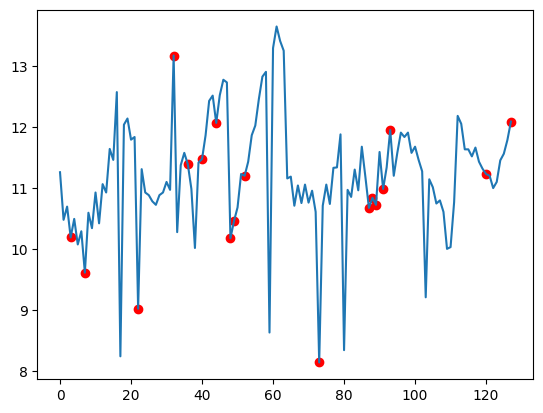

In [8]:
''' find and exclude noisy channels '''
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level)
plt.scatter(bad_idx_sorted, noise_level[bad_idx_sorted], c='r')
# plt.hlines(10, 0, 128)

In [9]:
# set noise threshold and remove noisy channels
n_channels = len(ch_names)
all_ch_idx = np.arange(n_channels)
noise_thresh = 11
keep_ch_idx = noise_level < noise_thresh
bad_channel_idx = all_ch_idx[~keep_ch_idx]

print(f"excluding {np.sum(~keep_ch_idx)} channel(s)")

excluding 77 channel(s)


In [11]:
bad_channel_idx = bad_idx_sorted

In [12]:
np.sort(bad_channel_idx)

array([  3,   7,  22,  32,  36,  40,  44,  48,  49,  52,  73,  87,  88,
        89,  91,  93, 120, 127])

In [13]:
# check the gain
gains = recording.get_channel_gains()
assert np.allclose(gains, gains[0]), "expected uniform gain across channels"
gain_to_uV = float(gains[0])   # typically 0.195 for Intan RHD-based systems
print()

In [18]:
# common median reference if needed
if cmr:
    rec_cmr = spre.common_reference(recording, reference="global", operator="median")
else:
    rec_cmr = recording

In [19]:
# to save files
sort_dir = f"{intan_folder}/bombcell/"

In [20]:
bad_channel_string = ''
for b_idx in bad_channel_idx:
    bad_channel_string = bad_channel_string + f'{b_idx}, '

print(f"Binary save path: {sort_dir}/traces_cached_seg0.raw")
print(f"Channel index to exlude: [{bad_channel_string}], fs: {fs}, gain_to_uV: {gain_to_uV}")

Binary save path: C:/Users/Isabel/Documents/data_temp/LIM64_260821/LIM64_260821_140105//bombcell//traces_cached_seg0.raw
Channel index to exlude: [97, 95, 93, 92, 91, 90, 89, 88, 87, 81, 126, 124, 104, 100, 96, 7, 0, 17, 30, 61, 59, 57, 55, 51, 47, 43, 60, 32, ], fs: 30000.0, gain_to_uV: 0.195


In [ ]:
# save as binary for KS4 and BC
rec_cmr.save(format="binary", folder=sort_dir, dtype="int16", 
             n_jobs=8, chunk_duration="1s")